# Load Merged Ratings Dataset


In [13]:

import pandas as pd

df = pd.read_csv("/merged_movies_ratings.csv")
df.head()


,movieID,title,genres,avg_rating,num_ratings
0,1454468,Gravity (2013),Drama|Sci-Fi|Thriller,8.230348,3104
1,816692,Interstellar (2014),Adventure|Drama|Sci-Fi,8.842266,2948
2,8579674,1917 (2019),Drama|War,8.617923,2879
3,993846,The Wolf of Wall Street (2013),Biography|Crime|Drama,8.389986,2836
4,7286456,Joker (2019),Crime|Drama|Thriller,9.082819,2753


# Load Revenue Dataset


In [32]:
# trying to load the box office data
revenue_df = pd.read_csv("/top_english_movies.csv", sep='\t')

# checking what the columns look like
cols = revenue_df.columns
print("these are the columns we got:")
print(cols)

# first few rows
revenue_df.head()


these are the columns we got:
Index(['Brand', 'Total', 'Releases', '#1 Release', 'Lifetime Gross'], dtype='object')


,Brand,Total,Releases,#1 Release,Lifetime Gross
0,Marvel Comics,15806336901,69,Avengers: Endgame,858373000
1,Legendary Pictures,7018798067,56,Jurassic World,652270625
2,Lucasfilm,6325022918,39,Star Wars: Episode VII - The Force Awakens,936662225
3,Pixar,6078217662,28,Incredibles 2,608581744
4,DC Comics,5815645953,46,The Dark Knight,533345358


# Clean and Parse Revenue Data


In [31]:
# trying to clean up the column names a bit
revenue_df.columns = revenue_df.columns.str.replace('\t', '')
revenue_df.columns = revenue_df.columns.str.replace(' ', '_')

# printing to see if it actually worked
print("Column names:")
print(revenue_df.columns)

revenue_df.head()

Column names:
Index(['Brand', 'Total', 'Releases', '#1_Release', 'Lifetime_Gross',
       'clean_title'],
      dtype='object')


,Brand,Total,Releases,#1_Release,Lifetime_Gross,clean_title
0,Marvel Comics,15806336901,69,Avengers: Endgame,858373000,avengers: endgame
1,Legendary Pictures,7018798067,56,Jurassic World,652270625,jurassic world
2,Lucasfilm,6325022918,39,Star Wars: Episode VII - The Force Awakens,936662225,star wars: episode vii - the force awakens
3,Pixar,6078217662,28,Incredibles 2,608581744,incredibles 2
4,DC Comics,5815645953,46,The Dark Knight,533345358,the dark knight


# Merge Ratings with Revenue by Title


In [20]:
# cleaning the movie titles so we can merge them later
df['clean_title'] = df['title'].str.replace(r"\s*\(\d{4}\)", "", regex=True)  # get rid of year like (2013)
df['clean_title'] = df['clean_title'].str.strip()
df['clean_title'] = df['clean_title'].str.lower()

# same thing for the revenue data
revenue_df['clean_title'] = revenue_df['#1_Release'].str.strip().str.lower()

# now trying to merge based on cleaned titles
merged = pd.merge(df, revenue_df, on='clean_title', how='inner')

# just seeing how many actually matched and what it looks like
print("how many matched movies:", merged.shape[0])
merged[['title', '#1_Release', 'avg_rating', 'num_ratings', 'Lifetime_Gross']].head()


how many matched movies: 52


,title,#1_Release,avg_rating,num_ratings,Lifetime_Gross
0,Star Wars: Episode VII - The Force Awakens (2015),Star Wars: Episode VII - The Force Awakens,8.438574,1571,936662225
1,Star Wars: Episode VII - The Force Awakens (2015),Star Wars: Episode VII - The Force Awakens,8.438574,1571,936662225
2,Avengers: Endgame (2019),Avengers: Endgame,9.046575,1460,858373000
3,Godzilla (2014),Godzilla,6.663468,1459,200676069
4,Jurassic World (2015),Jurassic World,7.313208,1325,652270625


# Feature Correlation Heatmap


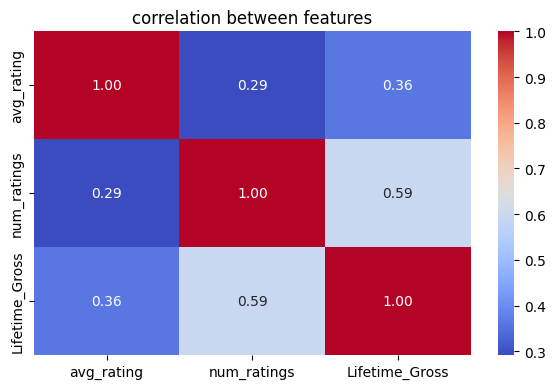

In [29]:

import seaborn as sns
import matplotlib.pyplot as plt

# make a basic correlation heatmap
plt.figure(figsize=(6, 4))
corr = merged[['avg_rating', 'num_ratings', 'Lifetime_Gross']].corr()

# draw the heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

# add a title to the plot
plt.title("correlation between features")
plt.tight_layout()
plt.show()


# Train Linear Regression Model


In [27]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# setting up the features (rating + number of ratings) and the thing we want to predict (gross revenue)
X = merged[['avg_rating', 'num_ratings']]  # input features
y = merged['Lifetime_Gross']  # target value

# splitting into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# make the linear regression model and train it
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)  # this is where the model learns

# now we use the model to predict
y_pred = lr_model.predict(X_test)  # predictions on test set


# Random Forest Model


In [26]:
# trying out a random forest regressor to see if it's better
from sklearn.ensemble import RandomForestRegressor


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# training the model
rf_model.fit(X_train, y_train)

# making predictions
rf_pred = rf_model.predict(X_test)

# checking how the random forest did
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# printing the results for random forest
print("Random Forest MAE:", "${:,.0f}".format(rf_mae))
print("Random Forest RMSE:", "${:,.0f}".format(rf_rmse))
print("Random Forest R^2:", round(rf_r2, 3))


Random Forest MAE: $165,600,187
Random Forest RMSE: $236,516,688
Random Forest R^2: -10.82


# Evaluate and Visualize Predictions


MAE: $154,236,732
RMSE: $192,435,764
R^2 Score: -6.825


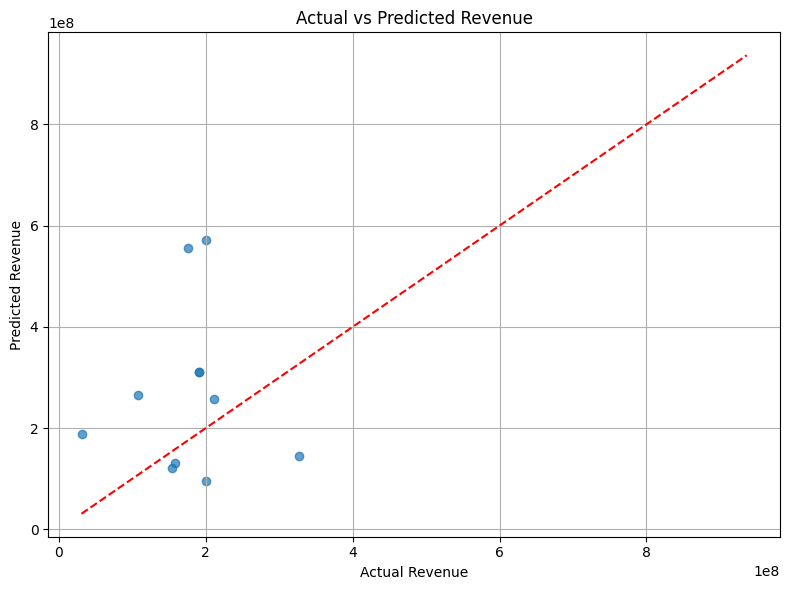

In [25]:
# checking how well the model did
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# printing out the errors to see how bad they are
print("MAE:", "${:,.0f}".format(mae))  # mean absolute error
print("RMSE:", "${:,.0f}".format(rmse))  # root mean square error
print("R^2 Score:", round(r2, 3))  # how well it fits (kinda low here)

# now let’s plot predicted vs actual to see how off we are
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

# add a red dotted line (ideal line)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.grid(True)
plt.tight_layout()
plt.show()
